# Training visualization — PD

End-to-end view of every continued-pretraining trial that
`scripts/train_pipeline.py` has produced — per-epoch loss/metric
curves, learning-rate schedule, cross-trial comparisons,
convergence diagnostics, and resource-usage trade-offs.

## Where the data comes from

Two artefacts written by the training pipeline:

* **Per-epoch CSV** — one file per trial under
  `output/training/epochs/<track>/<descriptive_name>.csv` with the
  schema `(epoch, train_loss, lr, metric_name, train_metric,
  test_metric, epoch_time_sec, elapsed_sec)`.
* **Run manifest CSV** — `output/training/manifests/<run_name>_<track>.csv`,
  one row per trial: hyperparameters, status (OK / FAIL), total
  walltime, the path of the final-epoch checkpoint.

All loading and plotting code lives in
`src/utils/training_viz.py`; this notebook contains only function
calls so the notebook stays scannable and the logic stays testable.

## What a 'trial' is

One trial = one `(base_checkpoint × learning_rate × use_lora)` tuple
from `cfg.tunable` in `config/train.yaml`. The full grid is the
Cartesian product, so a four-base / four-LR / {no-LoRA, LoRA}
sweep is 32 trials per track. SLURM array indices map 1-to-1 onto
trial indices.

## Direction of improvement

Higher is better for PD (`roc_auc`); lower is better for LGD
(`rmse`). Every helper in this notebook is direction-aware — `best`
and `sort_values` calls flip sign automatically.

## Sections

1. Setup and what's on disk
2. Per-trial dashboards (one model at a time)
3. Cross-trial loss & metric curves
4. Final-metric comparisons by hyperparameter
5. Time / accuracy trade-off
6. Convergence diagnostics
7. Failures and leaderboard

In [1]:
%matplotlib inline
import sys, os
from pathlib import Path
REPO = Path(os.getcwd()).resolve()
# pyproject.toml, not a module path: src/visualize/ used to be
# src/utils/ and this loop then walked past the repo root.
while not (REPO / 'pyproject.toml').exists() and REPO.parent != REPO:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

# `display` is an IPython builtin. src/utils/run_notebooks.py executes this file as
# a plain script to rebuild All_Results.md, where it is not — so import it.
from IPython.display import display

import pandas as pd
from src.visualize.figures import FigureSaver
from src.visualize import style
from src.visualize.training_viz import (
    load_run_manifest, load_epoch_history, load_all_epoch_histories,
    training_overview, trial_leaderboard, failed_trials,
    plot_loss_curve, plot_lr_schedule, plot_metric_curves,
    plot_epoch_time, plot_trial_dashboard,
    plot_loss_overlay, plot_metric_overlay, plot_overfitting_diagnostic,
    plot_final_metric_bar, plot_lr_effect, plot_lora_effect,
    plot_metric_heatmap, plot_base_ranking,
    plot_pareto_time_vs_metric, plot_epoch_time_overlay,
    plot_convergence_speed,
    plot_weight_drift, plot_per_dataset_loss,
)
pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
TRACK = 'pd'    # this notebook is fixed to the PD track
sink = FigureSaver('1.0. training_visualization_pd')

# One style for every figure in this project.
style.apply()


## 1 · What's on disk

Manifest tells us which trials were attempted and their outcome;
the per-epoch CSV count tells us how many of those produced any
training history.

In [2]:
manifest = load_run_manifest(TRACK)
manifest

,track,base_checkpoint,learning_rate,use_lora,query_fraction,accumulate_grad_batches,seed,n_train_datasets,n_test_datasets,final_ckpt_path,elapsed_sec,status,error,primary_metric_name,baseline_train_metric,baseline_test_metric,final_train_metric,final_test_metric,final_train_loss,secondary_metric_name,final_secondary_train,final_secondary_test,diverged_at_epoch,diverge_reason,epoch_pass_mode,trial_name,base_short,lr_tag
0,pd,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,False,0.4,1,42,12,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,6253.011874,OK,NaN,roc_auc,0.778280,0.714645,0.778357,0.715243,0.467766,brier_score,0.110088,0.161163,NaN,NaN,full_pass,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,3e-07
1,pd,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,False,0.2,1,42,12,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,6933.911446,OK,NaN,roc_auc,0.779718,0.721267,0.779602,0.721538,0.464553,brier_score,0.109874,0.161218,NaN,NaN,full_pass,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,3e-07
2,pd,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,1.000000e-06,False,0.2,1,42,12,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,6925.731826,OK,NaN,roc_auc,0.779718,0.721267,0.781115,0.721992,0.462393,brier_score,0.109360,0.161104,NaN,NaN,full_pass,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,1e-06
3,pd,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,True,0.4,1,42,12,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,7068.964320,OK,NaN,roc_auc,0.778280,0.714645,0.777812,0.714118,0.471968,brier_score,0.110366,0.161257,NaN,NaN,full_pass,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,3e-07
4,pd,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,True,0.2,1,42,12,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,7820.019679,OK,NaN,roc_auc,0.779718,0.721267,0.779487,0.720987,0.468339,brier_score,0.110141,0.161609,NaN,NaN,full_pass,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,3e-07
5,pd,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,1.000000e-06,False,0.4,1,42,12,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,6270.540040,OK,NaN,roc_auc,0.778280,0.714645,0.780225,0.714772,0.465611,brier_score,0.109478,0.161376,NaN,NaN,full_pass,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,1e-06
6,pd,checkpoints/tabpfn-v3-classifier-v3_default.ckpt,1.000000e-06,False,0.4,1,42,12,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,8550.957082,OK,NaN,roc_auc,0.778162,0.718228,0.785066,0.716328,0.440375,brier_score,0.108083,0.161056,NaN,NaN,full_pass,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,1e-06
7,pd,checkpoints/tabpfn-v3-classifier-v3_default.ckpt,3.000000e-07,False,0.4,1,42,12,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,8548.964420,OK,NaN,roc_auc,0.778162,0.718228,0.782588,0.716712,0.446839,brier_score,0.108778,0.160482,NaN,NaN,full_pass,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,3e-07
8,pd,checkpoints/tabpfn-v3-classifier-v3_default.ckpt,3.000000e-06,False,0.4,1,42,12,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,8551.677488,OK,NaN,roc_auc,0.778162,0.718228,0.786903,0.713244,0.434119,brier_score,0.108248,0.162298,NaN,NaN,full_pass,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,3e-06
9,pd,checkpoints/tabpfn-v3-classifier-v3_default.ckpt,3.000000e-07,True,0.4,1,42,12,5,/lustre1/project/stg_00211/CreditPFN/checkpoin...,8630.229316,OK,NaN,roc_auc,0.778162,0.718228,0.778087,0.718051,0.464135,brier_score,0.110457,0.159650,NaN,NaN,full_pass,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,3e-07


In [3]:
overview = training_overview(TRACK)
overview

,trial_name,base_short,base_checkpoint,learning_rate,use_lora,seed,status,elapsed_sec,n_train_datasets,n_test_datasets,n_epochs,final_train_loss,final_train_metric,final_test_metric,best_test_metric,best_epoch,metric_name,mean_epoch_sec
0,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,False,42,OK,6253.011874,12,5,46,0.467766,0.778357,0.715243,0.715312,35,roc_auc,135.516078
1,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,False,42,OK,6933.911446,12,5,46,0.464553,0.779602,0.721538,0.721600,40,roc_auc,150.300371
2,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,1.000000e-06,False,42,OK,6925.731826,12,5,46,0.462393,0.781115,0.721992,0.722150,40,roc_auc,150.141393
3,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,True,42,OK,7068.964320,12,5,46,0.471968,0.777812,0.714118,0.714805,0,roc_auc,153.246623
4,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,3.000000e-07,True,42,OK,7820.019679,12,5,46,0.468339,0.779487,0.720987,0.721404,15,roc_auc,169.573504
5,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,checkpoints/tabpfn-v2.6-classifier-v2.6_defaul...,1.000000e-06,False,42,OK,6270.540040,12,5,46,0.465611,0.780225,0.714772,0.715440,10,roc_auc,135.894781
6,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,checkpoints/tabpfn-v3-classifier-v3_default.ckpt,1.000000e-06,False,42,OK,8550.957082,12,5,101,0.440375,0.785066,0.716328,0.718273,0,roc_auc,84.443663
7,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,checkpoints/tabpfn-v3-classifier-v3_default.ckpt,3.000000e-07,False,42,OK,8548.964420,12,5,101,0.446839,0.782588,0.716712,0.718268,0,roc_auc,84.425171
8,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,checkpoints/tabpfn-v3-classifier-v3_default.ckpt,3.000000e-06,False,42,OK,8551.677488,12,5,101,0.434119,0.786903,0.713244,0.718247,0,roc_auc,84.451117
9,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,checkpoints/tabpfn-v3-classifier-v3_default.ckpt,3.000000e-07,True,42,OK,8630.229316,12,5,101,0.464135,0.778087,0.718051,0.718307,15,roc_auc,85.224969


## 2 · Per-trial dashboard

Pick one trial (any descriptive_name from the leaderboard). The
dashboard gives a 2×2 view of `loss`, `lr`, `train/test metric`,
and `epoch wall-clock` — useful for spotting one slow chunk, an
exploding loss, or a metric that's still climbing at the cliff.

In [4]:
# Default: the best-scoring trial in the overview. Override with any
# trial_name string to inspect that one instead.
FOCUS_TRIAL = (
    overview.sort_values('best_test_metric', ascending=(TRACK == 'lgd'))['trial_name'].iloc[0]
    if not overview.empty else 'creditpfn_pd_tabpfn-v3-classifier-v3_default_lr5e-05_seed42'
)
FOCUS_TRIAL

'creditpfn_pd_tabpfn-v3-classifier-v3_default_lr3e-06_seed42_qf20_acc1_fullpass'

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/01_trial_dashboard.pdf')

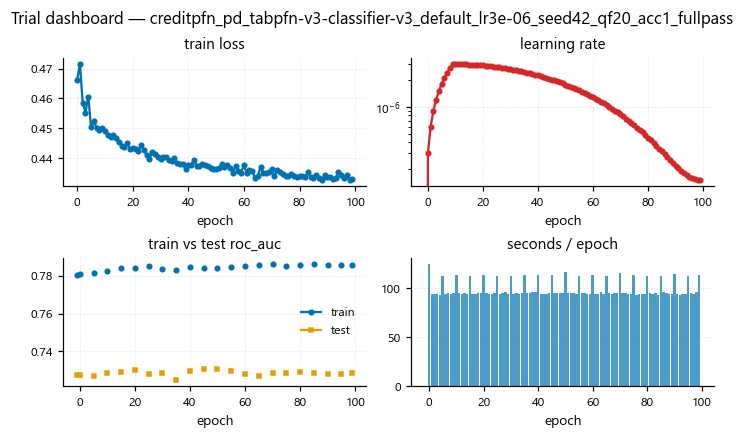

In [5]:
sink.save(plot_trial_dashboard(FOCUS_TRIAL, TRACK), 'trial_dashboard',
          caption="Four panels for the focus trial: training loss, learning-rate schedule, train and held-out monitoring metric, and wall-clock seconds, all against epoch.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/02_loss_curve.pdf')

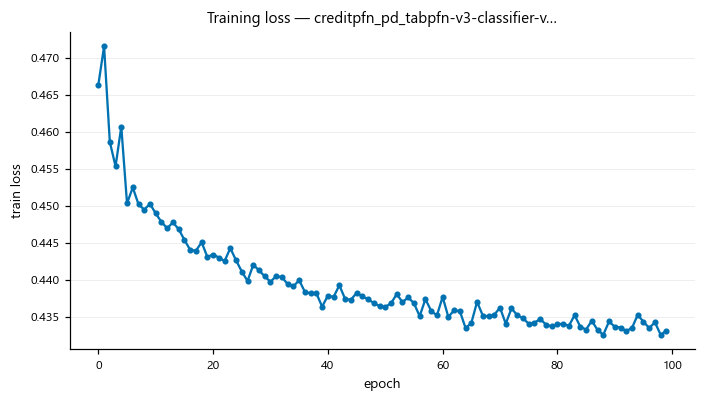

In [6]:
sink.save(plot_loss_curve(FOCUS_TRIAL, TRACK), 'loss_curve',
          caption="Training loss against epoch for the focus trial, averaged over the optimiser steps of each epoch.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/03_lr_schedule.pdf')

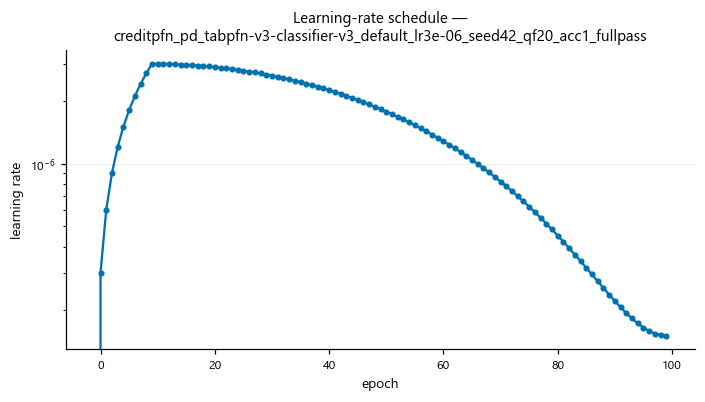

In [7]:
sink.save(plot_lr_schedule(FOCUS_TRIAL, TRACK), 'lr_schedule',
          caption="Learning rate against epoch for the focus trial: linear warmup followed by cosine decay to the configured floor.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/04_metric_curves.pdf')

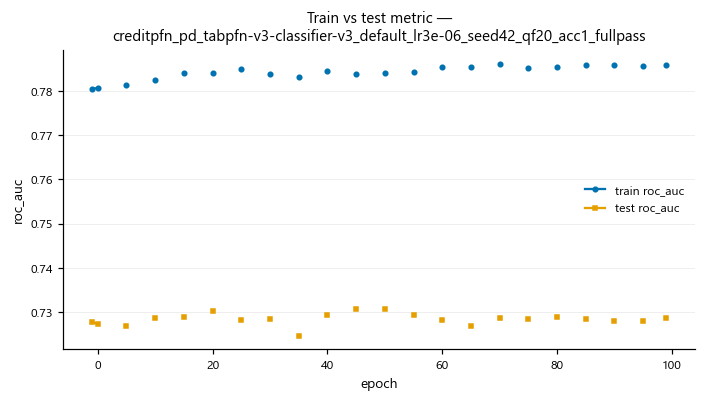

In [8]:
sink.save(plot_metric_curves(FOCUS_TRIAL, TRACK), 'metric_curves',
          caption="Monitoring metric against epoch for the focus trial, on the training datasets and on the held-out datasets, on twin axes. The monitor uses a fixed 2 000-row sample per dataset.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/05_epoch_time.pdf')

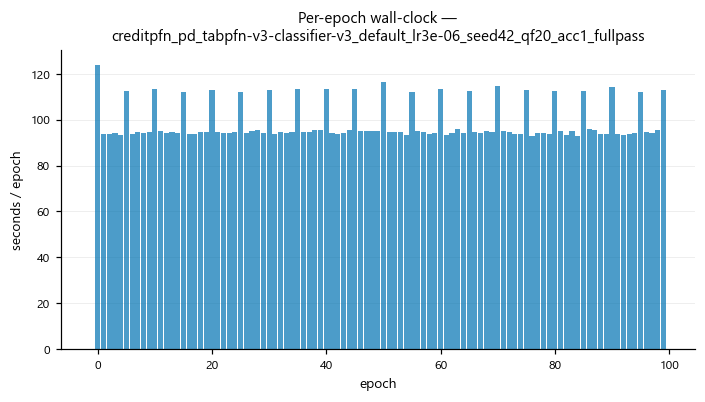

In [9]:
sink.save(plot_epoch_time(FOCUS_TRIAL, TRACK), 'epoch_time',
          caption="Wall-clock seconds per epoch for the focus trial.")

## 3 · Cross-trial overlays

Every trial on one axes. Colour = base checkpoint;
solid = no-LoRA, dashed = LoRA. Use these to spot regimes:

* If LoRA trials cluster well below no-LoRA ⇒ LoRA is hurting on
  this track and base.
* If one base sits clearly above the others throughout ⇒ pick that
  base as the headline checkpoint.
* If test_metric falls while train_metric keeps climbing ⇒ overfit
  starting; check the gap plot.

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/06_loss_overlay.pdf')

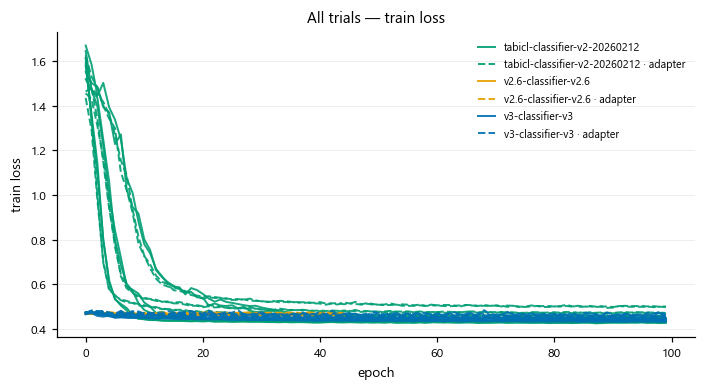

In [10]:
sink.save(plot_loss_overlay(TRACK), 'loss_overlay',
          caption="Training loss against epoch for every trial in the grid, one line per trial, coloured by base checkpoint and dashed for the adapter arm.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/07_metric_overlay.pdf')

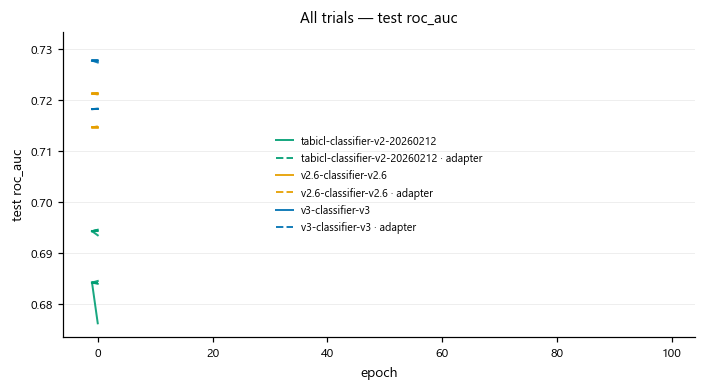

In [11]:
sink.save(plot_metric_overlay(TRACK, split='test'), 'metric_overlay',
          caption="Held-out monitoring metric against epoch for every trial, one line per trial, coloured by base checkpoint.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/08_metric_overlay.pdf')

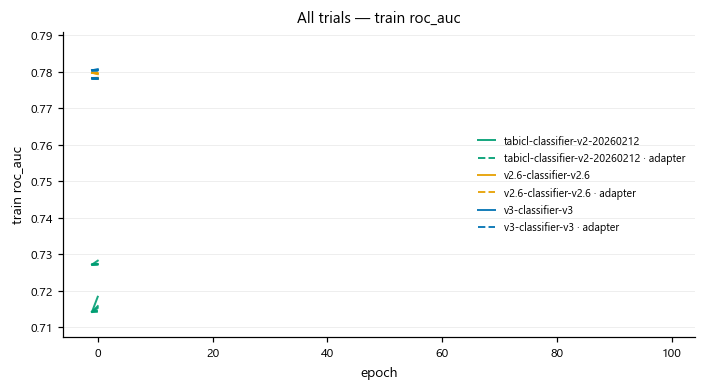

In [12]:
sink.save(plot_metric_overlay(TRACK, split='train'), 'metric_overlay',
          caption="Held-out monitoring metric against epoch for every trial, one line per trial, coloured by base checkpoint.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/09_overfitting_diagnostic.pdf')

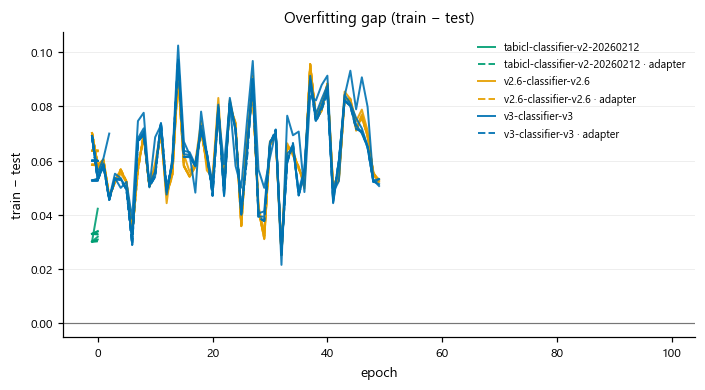

In [13]:
sink.save(plot_overfitting_diagnostic(TRACK), 'overfitting_diagnostic',
          caption="Training metric minus held-out metric against epoch, one line per trial. A rising line is the training corpus being fitted at the expense of unseen datasets.")

## 4 · Final-metric comparisons by hyperparameter

**`best_test_metric`** is the best test-set score the trial
achieved during training (max of `test_metric` for PD,
min for LGD).

**`final_test_metric`** is the last-epoch value (i.e. what the
checkpoint actually delivers on disk).

Swap the `metric=` kwarg below to view the latter instead.

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/10_final_metric_bar.pdf')

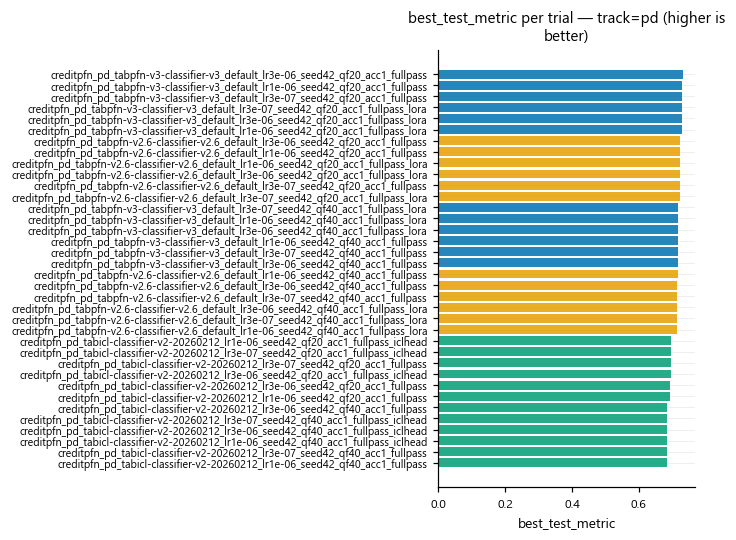

In [14]:
sink.save(plot_final_metric_bar(TRACK, metric='best_test_metric'), 'final_metric_bar',
          caption="Final monitoring metric per trial, sorted, one bar per trial, coloured by base checkpoint.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/11_metric_heatmap.pdf')

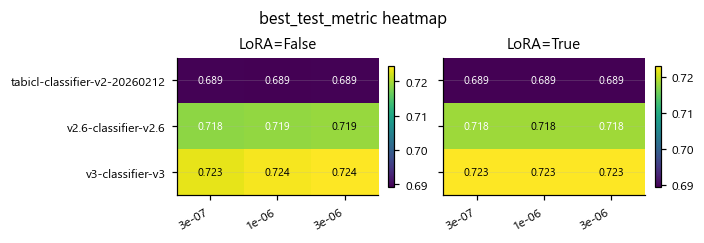

In [15]:
sink.save(plot_metric_heatmap(TRACK, metric='best_test_metric'), 'metric_heatmap',
          caption="Final monitoring metric over base checkpoint against learning rate, one panel per adaptation mode.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/12_lr_effect.pdf')

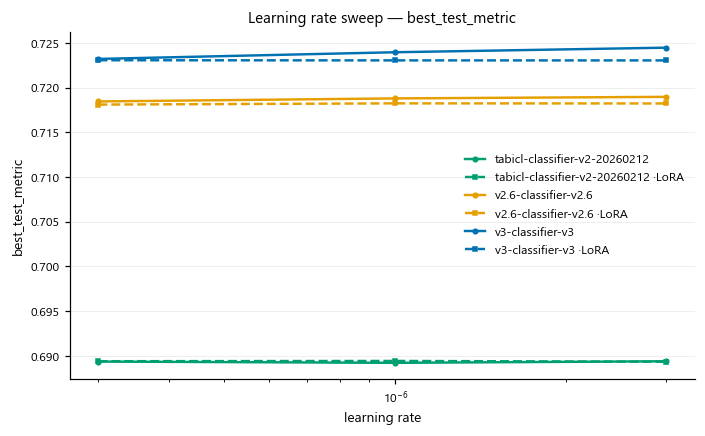

In [16]:
sink.save(plot_lr_effect(TRACK, metric='best_test_metric'), 'lr_effect',
          caption="Final monitoring metric against learning rate, one line per (base checkpoint, adaptation mode) pair.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/13_lora_effect.pdf')

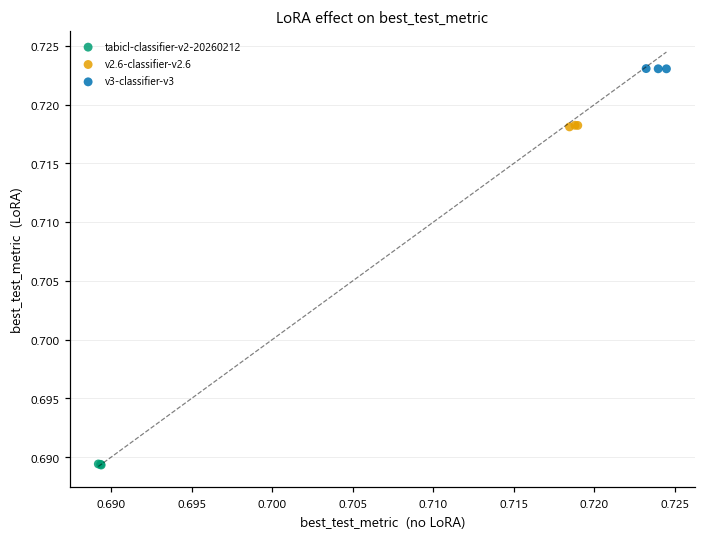

In [17]:
sink.save(plot_lora_effect(TRACK, metric='best_test_metric'), 'lora_effect',
          caption="Final monitoring metric of the full-finetuning arm against the adapter arm, paired within each (base, learning rate) pair. The diagonal marks equality.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/14_base_ranking.pdf')

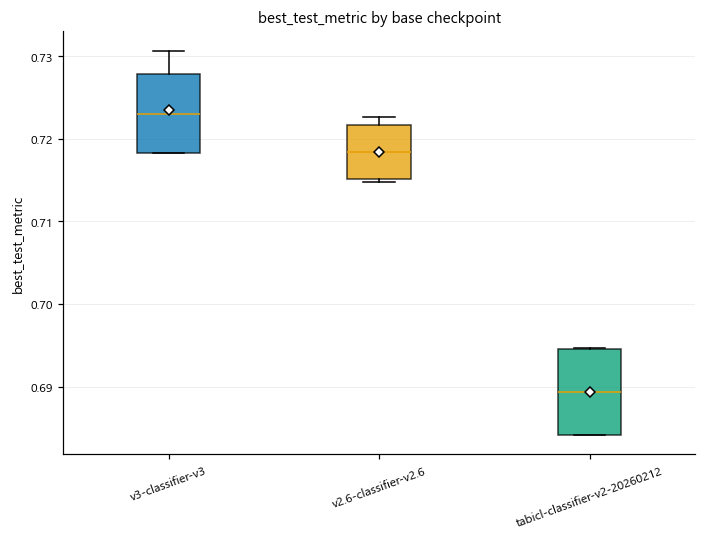

In [18]:
sink.save(plot_base_ranking(TRACK, metric='best_test_metric'), 'base_ranking',
          caption="Distribution of the final monitoring metric per base checkpoint, over all learning rates, adaptation modes and query fractions.")

## 5 · Time / accuracy trade-off

The Pareto-frontier-style scatter pairs **total training time** (x,
minutes) with the **final-epoch test metric** (y). A trial that
matches another's metric in less time pareto-dominates it.

The per-epoch bar plot underneath flags trials whose mean
seconds/epoch is unusually high — useful when one dataset's
chunk drags the whole epoch budget.

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/15_pareto_time_vs_metric.pdf')

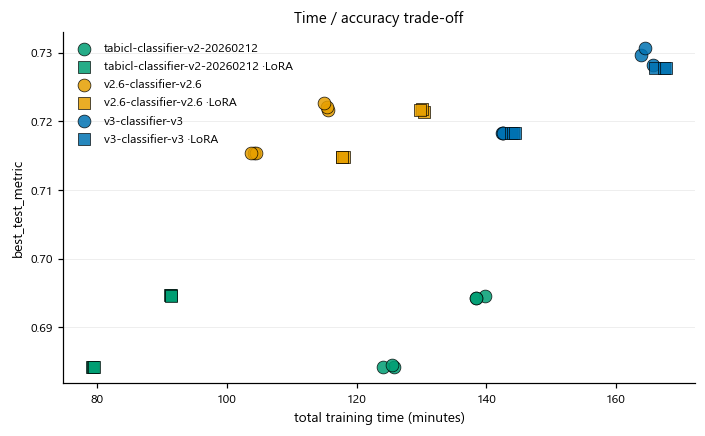

In [19]:
sink.save(plot_pareto_time_vs_metric(TRACK, metric='best_test_metric'), 'pareto_time_vs_metric',
          caption="Total training wall-clock against final monitoring metric, one point per trial, coloured by base checkpoint.")

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/16_epoch_time_overlay.pdf')

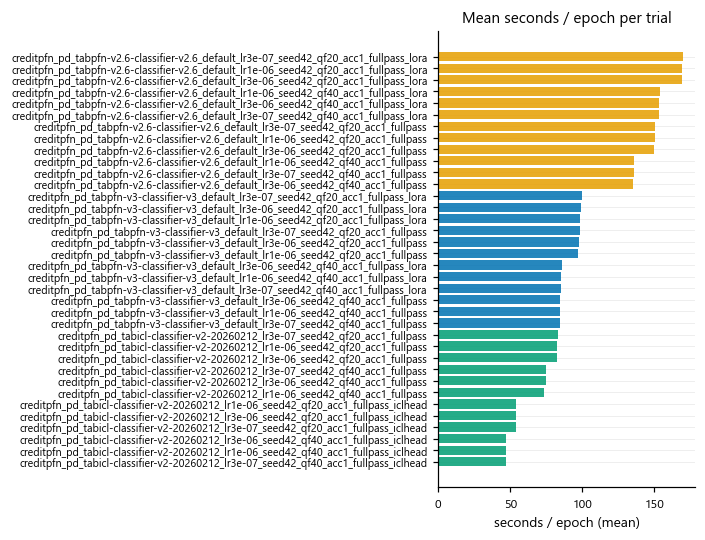

In [20]:
sink.save(plot_epoch_time_overlay(TRACK), 'epoch_time_overlay',
          caption="Median seconds per epoch per trial, one bar per trial, coloured by base checkpoint.")

## 6 · Convergence diagnostics

Where in the training budget does the best test metric appear?

* Most mass at < 30 % ⇒ early stop is leaving training cycles on
  the floor; consider shorter epochs or a stricter LR schedule.
* Most mass at > 80 % ⇒ trials are still improving when training
  ends; increase `cfg.train.epochs` before re-launching the sweep.

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/17_convergence_speed.pdf')

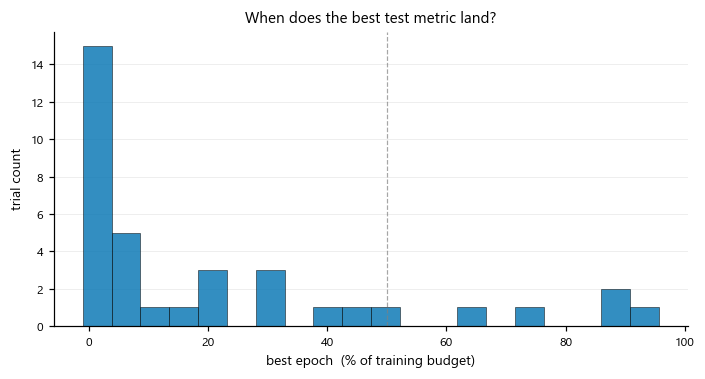

In [21]:
sink.save(plot_convergence_speed(TRACK), 'convergence_speed',
          caption="Distribution of the epoch at which each trial reached its best held-out monitoring metric.")

## 7 · Failures and leaderboard

`failed_trials()` surfaces any FAIL rows from the manifest with
their error string — most often a `CUDA OOM` from a too-large
`n_finetune_ctx_plus_query_samples`. The leaderboard at the end
is the canonical sorted view used to pick the headline
checkpoint for eval.

In [22]:
failures = failed_trials(TRACK)
if failures.empty:
    print('No failed trials. ✔')
else:
    display(failures)

No failed trials. ✔


In [23]:
trial_leaderboard(TRACK)

,trial_name,base_short,learning_rate,use_lora,seed,metric_name,best_test_metric,best_epoch,final_test_metric,final_train_metric,n_epochs,mean_epoch_sec,elapsed_sec,status
0,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,3.000000e-06,False,42,roc_auc,0.730697,45,0.728556,0.785756,101,97.462982,9866.617106,OK
1,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,1.000000e-06,False,42,roc_auc,0.729649,20,0.727887,0.786451,101,97.163286,9835.993716,OK
2,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,3.000000e-07,False,42,roc_auc,0.728158,50,0.727900,0.783572,101,98.180008,9938.728150,OK
3,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,3.000000e-07,True,42,roc_auc,0.727824,10,0.727363,0.780354,101,99.426919,10064.236789,OK
4,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,3.000000e-06,True,42,roc_auc,0.727806,40,0.727500,0.780862,101,99.214175,10042.836356,OK
5,creditpfn_pd_tabpfn-v3-classifier-v3_default_l...,v3-classifier-v3,1.000000e-06,True,42,roc_auc,0.727801,5,0.727176,0.780696,101,98.446235,9965.875151,OK
6,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,3.000000e-06,False,42,roc_auc,0.722611,15,0.722085,0.781907,46,149.570245,6899.766299,OK
7,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,1.000000e-06,False,42,roc_auc,0.722150,40,0.721992,0.781115,46,150.141393,6925.731826,OK
8,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,1.000000e-06,True,42,roc_auc,0.721720,30,0.721700,0.779118,46,169.280576,7806.286948,OK
9,creditpfn_pd_tabpfn-v2.6-classifier-v2.6_defau...,v2.6-classifier-v2.6,3.000000e-06,True,42,roc_auc,0.721626,44,0.721626,0.778764,46,168.931879,7790.525207,OK


## 8. Did the model actually move?

`drift__<stage>` is $\|w - w_0\|$ over one top-level module of the model, recorded on
every monitored epoch. This is the plot that reframed run-5: a trial whose drift stays
flat near zero has **not trained**, so its "no effect" result says nothing about
continued pretraining. Below it, the per-dataset loss shows *which* tables the model is
learning — a corpus loss that falls while one dataset's loss rises is the model trading
one table off against the others.

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/18_weight_drift.pdf')

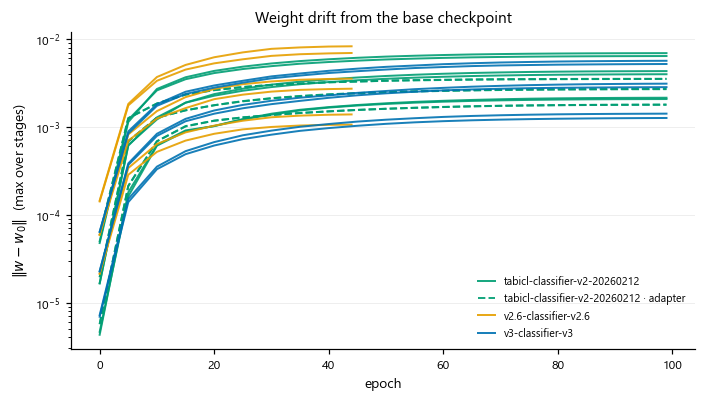

In [24]:
sink.save(plot_weight_drift(TRACK), 'weight_drift',
          caption="Distance of each trial's weights from its base checkpoint against epoch, on a log axis, taking the maximum over the model's top-level stages. One line per trial, coloured by base checkpoint.")


WindowsPath('C:/Users/U0152019/PhD Documents/Projects/3. CreditPFN/CreditPFN/output/figures/1.0. training_visualization_pd/19_per_dataset_loss.pdf')

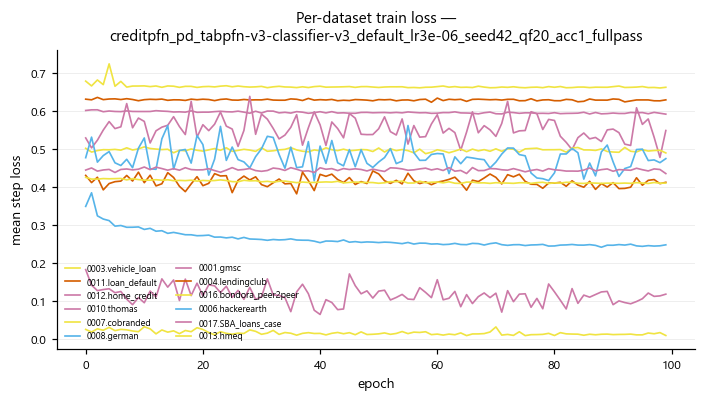

In [25]:
sink.save(plot_per_dataset_loss(FOCUS_TRIAL, TRACK), 'per_dataset_loss',
          caption="Mean training loss per dataset against epoch for the focus trial, one line per training dataset, ordered in the legend by final loss.")


In [26]:
lb = trial_leaderboard(TRACK)
print(f'## 1.0 training visualization ({TRACK})')
print(f'trials in manifest: {len(lb)}')
print(lb.to_string() if len(lb) else '  no trials')
print()
print(sink.summary())


## 1.0 training visualization (pd)
trials in manifest: 36
                                                                                 trial_name                     base_short  learning_rate  use_lora  seed metric_name  best_test_metric  best_epoch  final_test_metric  final_train_metric  n_epochs  mean_epoch_sec   elapsed_sec status
0            creditpfn_pd_tabpfn-v3-classifier-v3_default_lr3e-06_seed42_qf20_acc1_fullpass               v3-classifier-v3   3.000000e-06     False    42     roc_auc          0.730697          45           0.728556            0.785756       101       97.462982   9866.617106     OK
1            creditpfn_pd_tabpfn-v3-classifier-v3_default_lr1e-06_seed42_qf20_acc1_fullpass               v3-classifier-v3   1.000000e-06     False    42     roc_auc          0.729649          20           0.727887            0.786451       101       97.163286   9835.993716     OK
2            creditpfn_pd_tabpfn-v3-classifier-v3_default_lr3e-07_seed42_qf20_acc1_fullpass     